In [17]:
import numpy as np
import math
import matplotlib.pyplot as plt
plt.style.use('default')
import matplotlib
import pandas as pd
import os
import re
from tqdm import tqdm
from dspeed.processors.trap_filters import trap_norm
from tools import load_waveform_data, compute_pickoff_values_and_plot_random, add_tail_slope_to_dataframe,calculate_tail_slope, query_and_plot_waveform
color_array=np.linspace(0,1,11)
cmap = plt.cm.tab20b

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>")) #makes the notebook wider
plt.style.use('default')
import h5py


#set the detector name and inout conditions for the trap filter
detector = 'P00698A' # 'P00698A' 'V07647A' 'P42575A' 'ponama_1' 'V00048A' 'P00749A' 'P00661B' 'V02166B'  'UNC_scanner'
sim_time=16000
step_time_out = 16
rise = 10000 
flat = 3000
pickoff = 13000



#directory at which the waveforms are located
directory = f'/nas/longleaf/home/kbhimani/EH-Drift/waveforms/{detector}'
time = np.linspace(start=step_time_out, stop= sim_time, num= (int) (sim_time/step_time_out))

100%|██████████| 1/1 [00:01<00:00,  1.48s/it]


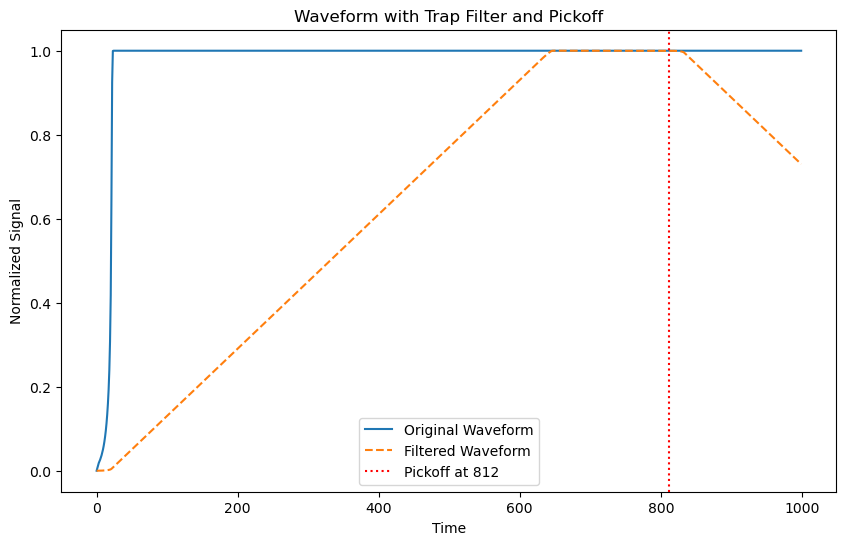

In [18]:
# Loads the waveforms into a pandas df
waveforms_df = load_waveform_data(directory)
# Apply Trap filter to all waveforms in the df
activeness = compute_pickoff_values_and_plot_random(waveforms_df, rise_samp := math.floor(rise/step_time_out), flat_samp := math.floor(flat/step_time_out), pickoff_samp := math.floor(pickoff/step_time_out), plot_random=True)

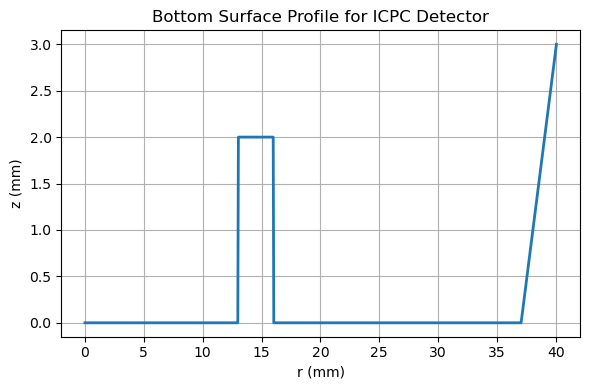

In [19]:
#This code helps plot the bottom boundary of detectors. This logic is used to export the activness maps in terms of r, depth in MPP input

import matplotlib.pyplot as plt
import numpy as np
import yaml
import os

# Detector geometry
det = "V05261A"  # V05261A B00000A P00698A
yaml_dir = '/nas/longleaf/home/kbhimani/EH-Drift/Analysis/ge_det_geo_analysis/legend-detectors/germanium/diodes'
yaml_path = os.path.join(yaml_dir, f"{det}.yaml")

with open(yaml_path, 'r') as f:
    metadata = yaml.safe_load(f)

# Read geometry and type from YAML
geom          = metadata['geometry']
det_type      = metadata.get('type', '').lower()
radius        = geom['radius_in_mm']
pc_radius     = geom.get('pp_contact', {}).get('radius_in_mm', 0)
pc_depth      = geom.get('pp_contact', {}).get('depth_in_mm', 0)
taper         = geom.get('taper', {}).get('bottom', {})
taper_angle   = taper.get('angle_in_deg', 0)
taper_h       = taper.get('height_in_mm', 0)

# Flat‐PC detectors: ICPC and BEGe
is_flat_pc    = det_type in ('icpc', 'bege')

# Groove parameters (only for flat‐PC detectors)
groove        = geom.get('groove', {}) if is_flat_pc else {}
groove_depth  = groove.get('depth_in_mm', 0)
groove_inner  = groove.get('radius_in_mm', {}).get('inner', 0)
groove_outer  = groove.get('radius_in_mm', {}).get('outer', 0)

# Compute taper slope and taper start radius
slope         = np.tan(np.radians(taper_angle)) if taper_angle != 0 else np.inf
taper_start_r = radius - taper_h / slope if slope != 0 else radius

# Build bottom‐surface contour
r_vals = np.linspace(0, radius, 800)
z_vals = []

for r in r_vals:
    if r <= pc_radius:
        # Point contact region
        if is_flat_pc:
            # Flat point contact at depth
            z = pc_depth
        else:
            # Hemispherical PPC point contact
            z = np.sqrt(pc_radius**2 - r**2)
    elif is_flat_pc and groove_inner <= r <= groove_outer:
        # Rectangular groove region
        z = groove_depth
    elif r <= taper_start_r:
        # Flat bottom outside point contact/groove
        z = 0
    else:
        # Tapered slope rising from z=0 to z=taper_h
        z = (r - taper_start_r) * slope
    z_vals.append(z)

# Plotting
plt.figure(figsize=(6,4))
plt.plot(r_vals, z_vals, lw=2)
plt.xlabel('r (mm)')
plt.ylabel('z (mm)')
plt.title(f'Bottom Surface Profile for {det_type.upper()} Detector')
plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
import os
import pandas as pd
import yaml
import numpy as np

# waveforms_df must already be loaded with columns:
# ['r', 'z', 'eng', 'energy_estimate', 'det', 'sc']
assert not waveforms_df.empty, "waveforms_df is empty – load your data first!"
required = {'r','z','eng','energy_estimate','det','sc'}
missing = required - set(waveforms_df.columns)
assert not missing, f"Missing columns: {missing}"

# Assign activeness
waveforms_df['activeness'] = waveforms_df['energy_estimate']

# Output headers
output_cols  = ['r','z','eng','activeness']
header_names = ['r (mm)','z (mm)','eng (keV)','activeness']

yaml_dir = '/nas/longleaf/home/kbhimani/EH-Drift/Analysis/ge_det_geo_analysis/legend-detectors/germanium/diodes'

def surface_points(geom, det_type, n_pts=1000):
    """Generate (r, z) samples along the bottom surface."""
    radius    = geom['radius_in_mm']
    pc_rad    = geom.get('pp_contact', {}).get('radius_in_mm', 0)
    pc_dep    = geom.get('pp_contact', {}).get('depth_in_mm', 0)
    taper     = geom.get('taper', {}).get('bottom', {})
    angle     = taper.get('angle_in_deg', 0)
    taper_h   = taper.get('height_in_mm', 0)
    flat_pc   = det_type in ('icpc','bege')
    groove    = geom.get('groove', {}) if flat_pc else {}
    g_in      = groove.get('radius_in_mm',{}).get('inner',0)
    g_out     = groove.get('radius_in_mm',{}).get('outer',0)
    g_dep     = groove.get('depth_in_mm',0)

    slope         = np.tan(np.radians(angle)) if angle else np.inf
    taper_start_r = radius - taper_h / slope if slope else radius

    r_vals = np.linspace(0, radius, n_pts)
    z_vals = np.zeros_like(r_vals)

    for i, r in enumerate(r_vals):
        if r <= pc_rad:
            z = pc_dep if flat_pc else np.sqrt(pc_rad**2 - r**2)
        elif flat_pc and g_in <= r <= g_out:
            z = g_dep
        elif r <= taper_start_r:
            z = 0.0
        else:
            z = (r - taper_start_r) * slope
        z_vals[i] = z

    return r_vals, z_vals

def depth_from_surface(r_hit, z_hit, geom, det_type):
    """Compute minimal distance to surface points strictly below the hit."""
    r_surf, z_surf = surface_points(geom, det_type)
    # only consider surface points at or below hit (z_surf <= z_hit)
    mask = z_surf <= z_hit
    if not np.any(mask):
        return 0.0
    dsq = (r_hit - r_surf[mask])**2 + (z_hit - z_surf[mask])**2
    return float(np.sqrt(dsq.min()))

for det in waveforms_df['det'].unique():
    yaml_path = os.path.join(yaml_dir, f"{det}.yaml")
    if not os.path.exists(yaml_path):
        print(f"YAML not found for {det}, skipping.")
        continue

    with open(yaml_path, 'r') as f:
        meta = yaml.safe_load(f)

    geom     = meta['geometry']
    det_type = meta.get('type','').lower()

    for sc in waveforms_df['sc'].unique():
        sub = waveforms_df[(waveforms_df['det']==det) & (waveforms_df['sc']==sc)].copy()
        if sub.empty:
            continue

        # compute depth and overwrite 'z'
        sub['z'] = sub.apply(
            lambda row: depth_from_surface(row['r'], row['z'], geom, det_type),
            axis=1
        )

        # round and prepare output
        sub['r']   = sub['r'].round(3)
        sub['z']   = sub['z'].round(3)
        sub['eng'] = sub['eng'].round(3)
        out = sub[output_cols].copy()
        out.columns = header_names

        # save
        out_dir = f"/nas/longleaf/home/kbhimani/EH-Drift/Analysis/mpp_input/{det}/sc={sc}"
        os.makedirs(out_dir, exist_ok=True)
        path = os.path.join(out_dir, f"activeness_map_{det}_sc={sc}.txt")
        out.to_csv(path, index=False)
        print(f"Saved: {path}")


Saved: /nas/longleaf/home/kbhimani/EH-Drift/Analysis/mpp_input/P00698A/sc=-0.3/activeness_map_P00698A_sc=-0.3.txt
Saved: /nas/longleaf/home/kbhimani/EH-Drift/Analysis/mpp_input/P00698A/sc=0.3/activeness_map_P00698A_sc=0.3.txt
Saved: /nas/longleaf/home/kbhimani/EH-Drift/Analysis/mpp_input/P00698A/sc=0.0/activeness_map_P00698A_sc=0.0.txt
Saved: /nas/longleaf/home/kbhimani/EH-Drift/Analysis/mpp_input/P00698A/sc=-0.03/activeness_map_P00698A_sc=-0.03.txt
Saved: /nas/longleaf/home/kbhimani/EH-Drift/Analysis/mpp_input/P00698A/sc=0.03/activeness_map_P00698A_sc=0.03.txt
Saved: /nas/longleaf/home/kbhimani/EH-Drift/Analysis/mpp_input/P00698A/sc=-0.15/activeness_map_P00698A_sc=-0.15.txt
Saved: /nas/longleaf/home/kbhimani/EH-Drift/Analysis/mpp_input/P00698A/sc=0.15/activeness_map_P00698A_sc=0.15.txt
Saved: /nas/longleaf/home/kbhimani/EH-Drift/Analysis/mpp_input/P00698A/sc=-0.5/activeness_map_P00698A_sc=-0.5.txt


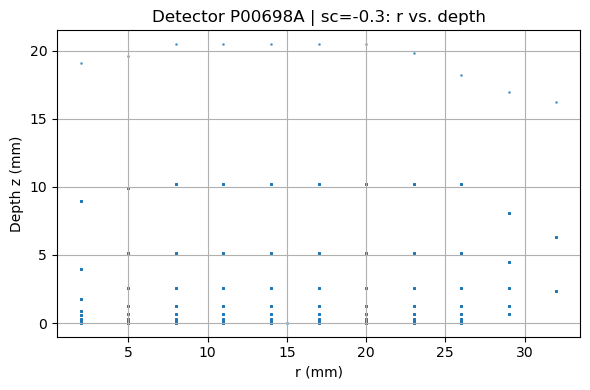

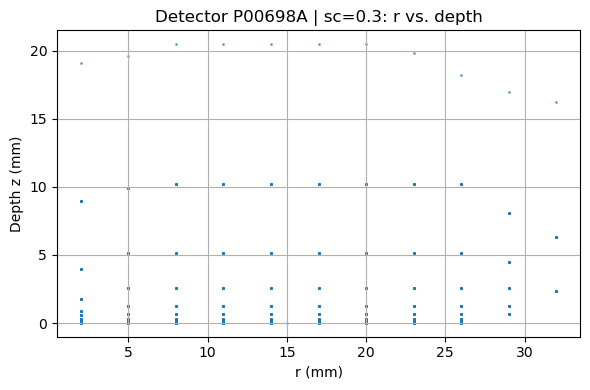

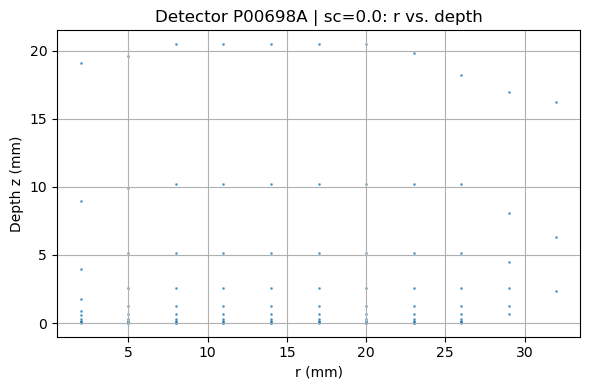

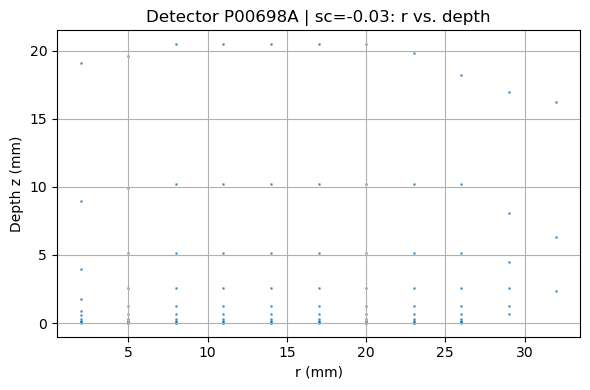

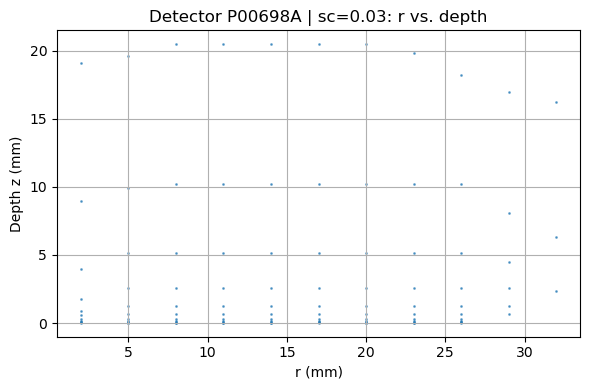

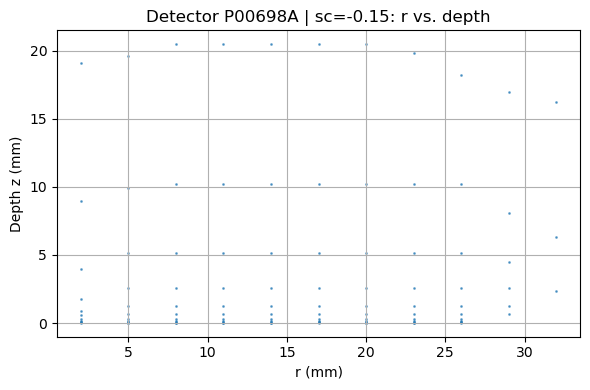

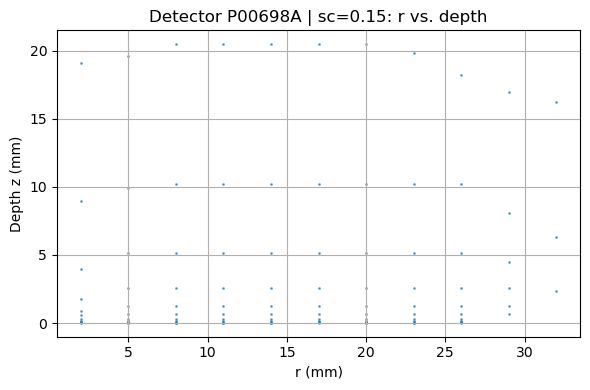

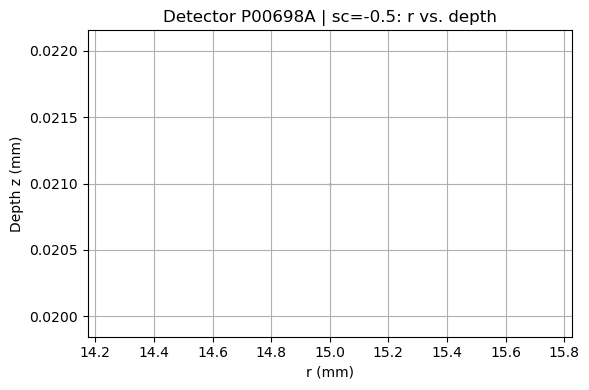

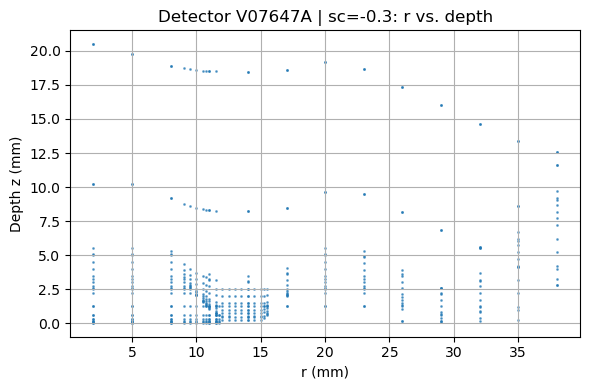

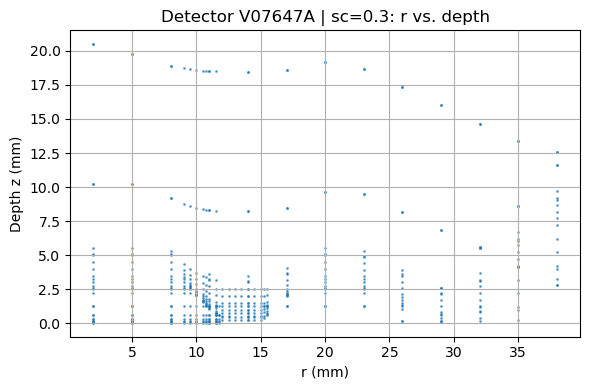

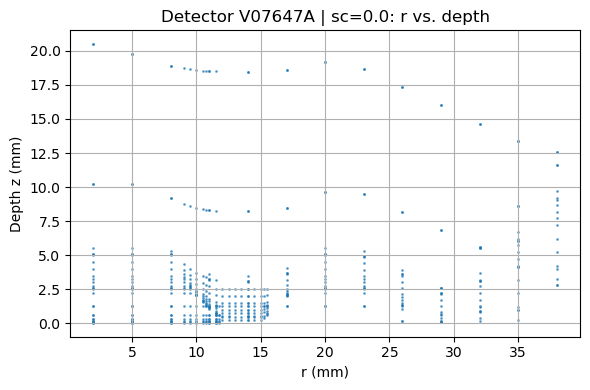

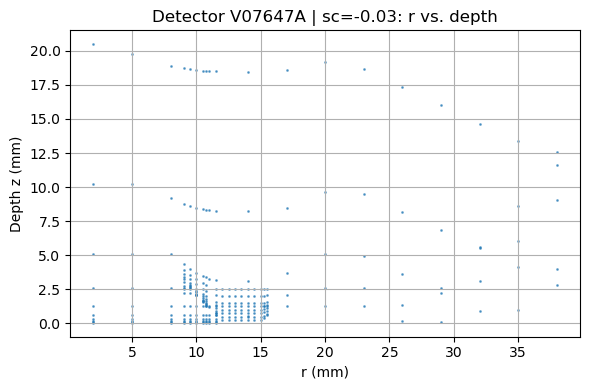

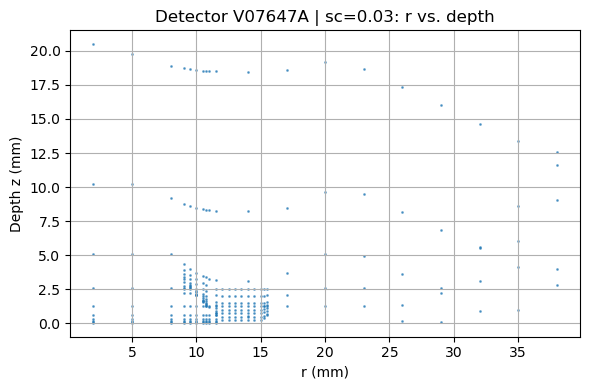

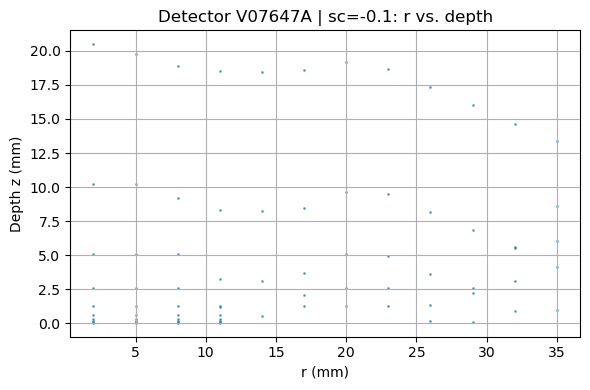

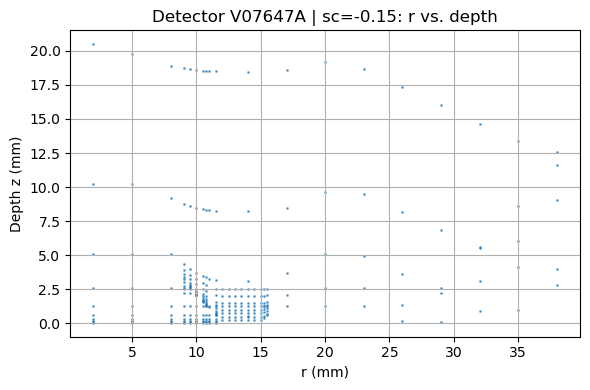

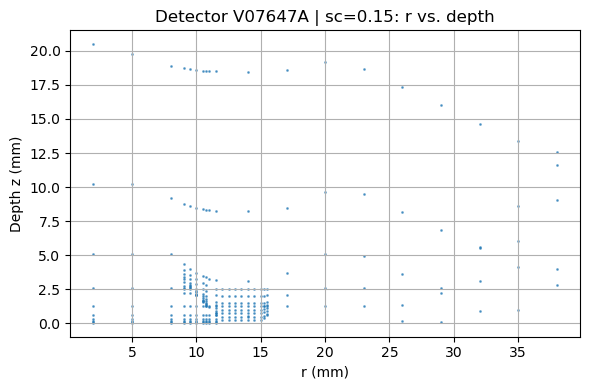

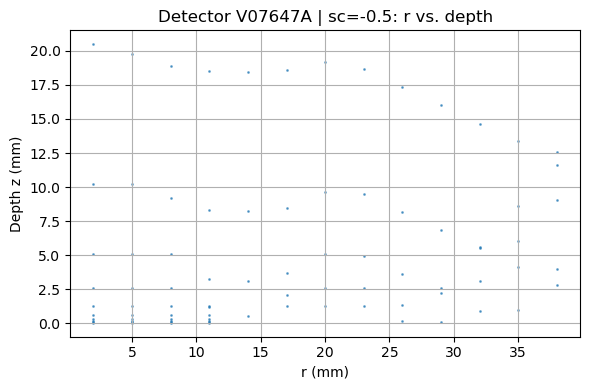

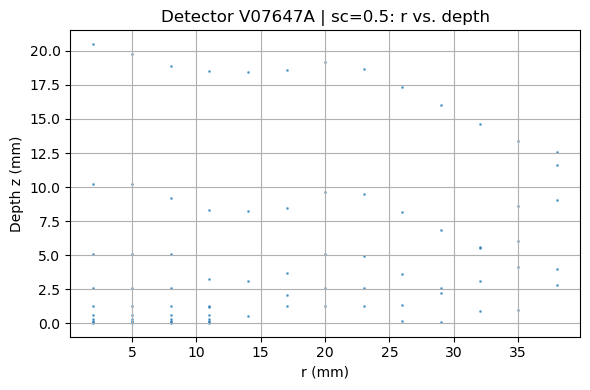

In [21]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# Base directory where activeness maps are saved
base_dir = '/nas/longleaf/home/kbhimani/EH-Drift/Analysis/mpp_input'

# Find all activeness map files
pattern = os.path.join(base_dir, '*', 'sc=*', 'activeness_map_*.txt')
files = glob.glob(pattern)

for file_path in files:
    # Extract detector and sc from the file path
    parts = file_path.split(os.sep)
    det = parts[-3]
    sc  = parts[-2].split('=')[1]
    
    # Load the data
    df = pd.read_csv(file_path)
    
    # Plot r vs. depth
    plt.figure(figsize=(6,4))
    plt.scatter(df['r (mm)'], df['z (mm)'], s=1, alpha=0.6)
    plt.xlabel('r (mm)')
    plt.ylabel('Depth z (mm)')
    plt.title(f'Detector {det} | sc={sc}: r vs. depth')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [6]:
#Zip the file, mkaing it easier to download
import shutil

folder_path = "/nas/longleaf/home/kbhimani/EH-Drift/Analysis/mpp_input" 
zip_path = "/nas/longleaf/home/kbhimani/EH-Drift/Analysis/mpp_input.zip"

folder_path = "/nas/longleaf/home/kbhimani/EH-Drift"
zip_path = "/nas/longleaf/home/kbhimani/EH-Drift.zip"

# Compress the folder
shutil.make_archive(zip_path.replace(".zip", ""), 'zip', folder_path)

print("Folder zipped successfully!")


Folder zipped successfully!
